**<head>PROJET MLOPS - Version MLF0 (MLflow)</head>**

In [180]:
# !pip install  statsmodels 
# !pip install xgboost
# !pip install scikit-learn
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install scipy
# !pip install scikit-learn
# !pip install pandas
# !pip install imbalanced-learn
#!pip install -U scikit-learn imbalanced-learn
#!pip install mlflow


In [181]:
# Importation des bibliothèques nécessaires
import sklearn
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
seeds = 42

# [MLF0] Ajout des imports MLflow
import mlflow
import mlflow.sklearn
from imblearn.over_sampling import SMOTE

In [182]:
# [MLF0] Configuration MLflow
mlflow.set_tracking_uri("mlruns")  # Stockage local dans le dossier mlruns
mlflow.set_experiment("ProjetMLOPS-LoanDefault3")  # Nom de l'expérience
print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow experiment : ProjetMLOPS-LoanDefault")

2026/04/03 16:25:52 INFO mlflow.tracking.fluent: Experiment with name 'ProjetMLOPS-LoanDefault3' does not exist. Creating a new experiment.


MLflow tracking URI : mlruns
MLflow experiment : ProjetMLOPS-LoanDefault


In [183]:
# Chargement du jeu de données
data = pd.read_csv('Loan_data.csv')
# [FIX] Conversion des types pandas StringDtype en types numpy natifs (requis pour joblib/GridSearchCV)
for col in data.select_dtypes(include='string').columns:
    data[col] = data[col].astype(object)
# Description du jeu de données
display(data.shape)
display(data.size)
displaydescribe = data.describe()

# Affichage des premières lignes du jeu de données
display(data.head())
display(displaydescribe)

(10000, 8)

80000

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [184]:
print( data['default'].value_counts())

default
0    8149
1    1851
Name: count, dtype: int64


In [185]:
# NOTE : Le scaling prématuré sur tout le dataset (y compris la target) a été supprimé.
# Le scaling est correctement réalisé dans le Pipeline (StandardScaler avant chaque modèle),
# ce qui évite tout data leakage lié au preprocessing.
# L'ancien code faisait : scaler.fit_transform(data) sur TOUTES les colonnes avant le split.

In [186]:
#Analyse des données manquantes
data.isnull().sum()
if data.isnull().sum().any():
    print("Il y a des données manquantes dans le dataset.")
else:
    print("Il n'y a pas de données manquantes dans le dataset.")

Il n'y a pas de données manquantes dans le dataset.


In [187]:
# Analyse des types de données
display(data.dtypes)
# Analyse des valeurs uniques
for column in data.columns:
    unique_values = data[column].nunique()
    print(f"Colonne '{column}' a {unique_values} valeurs uniques.")
else:
    print("Aucune colonne n'a qu'une seule valeur unique.")

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

Colonne 'customer_id' a 10000 valeurs uniques.
Colonne 'credit_lines_outstanding' a 6 valeurs uniques.
Colonne 'loan_amt_outstanding' a 10000 valeurs uniques.
Colonne 'total_debt_outstanding' a 10000 valeurs uniques.
Colonne 'income' a 9995 valeurs uniques.
Colonne 'years_employed' a 11 valeurs uniques.
Colonne 'fico_score' a 374 valeurs uniques.
Colonne 'default' a 2 valeurs uniques.
Aucune colonne n'a qu'une seule valeur unique.


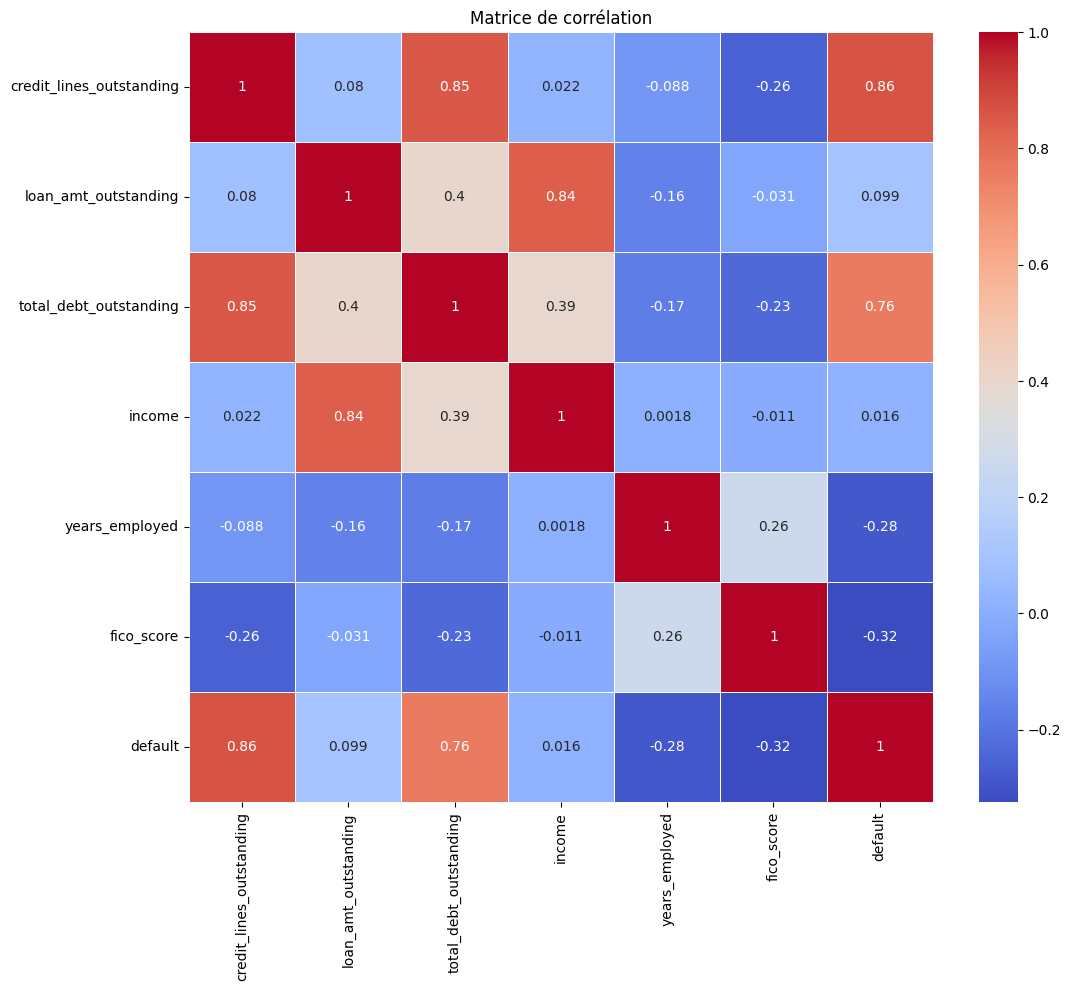

Correlations supérieures à 0,75 :


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.000000,NaN,0.852210,NaN,NaN,NaN,0.862815
loan_amt_outstanding,NaN,1.000000,NaN,0.835815,NaN,NaN,NaN
total_debt_outstanding,0.852210,NaN,1.000000,NaN,NaN,NaN,0.758868
income,NaN,0.835815,NaN,1.000000,NaN,NaN,NaN
years_employed,NaN,NaN,NaN,NaN,1.0,NaN,NaN
fico_score,NaN,NaN,NaN,NaN,NaN,1.0,NaN
default,0.862815,NaN,0.758868,NaN,NaN,NaN,1.000000


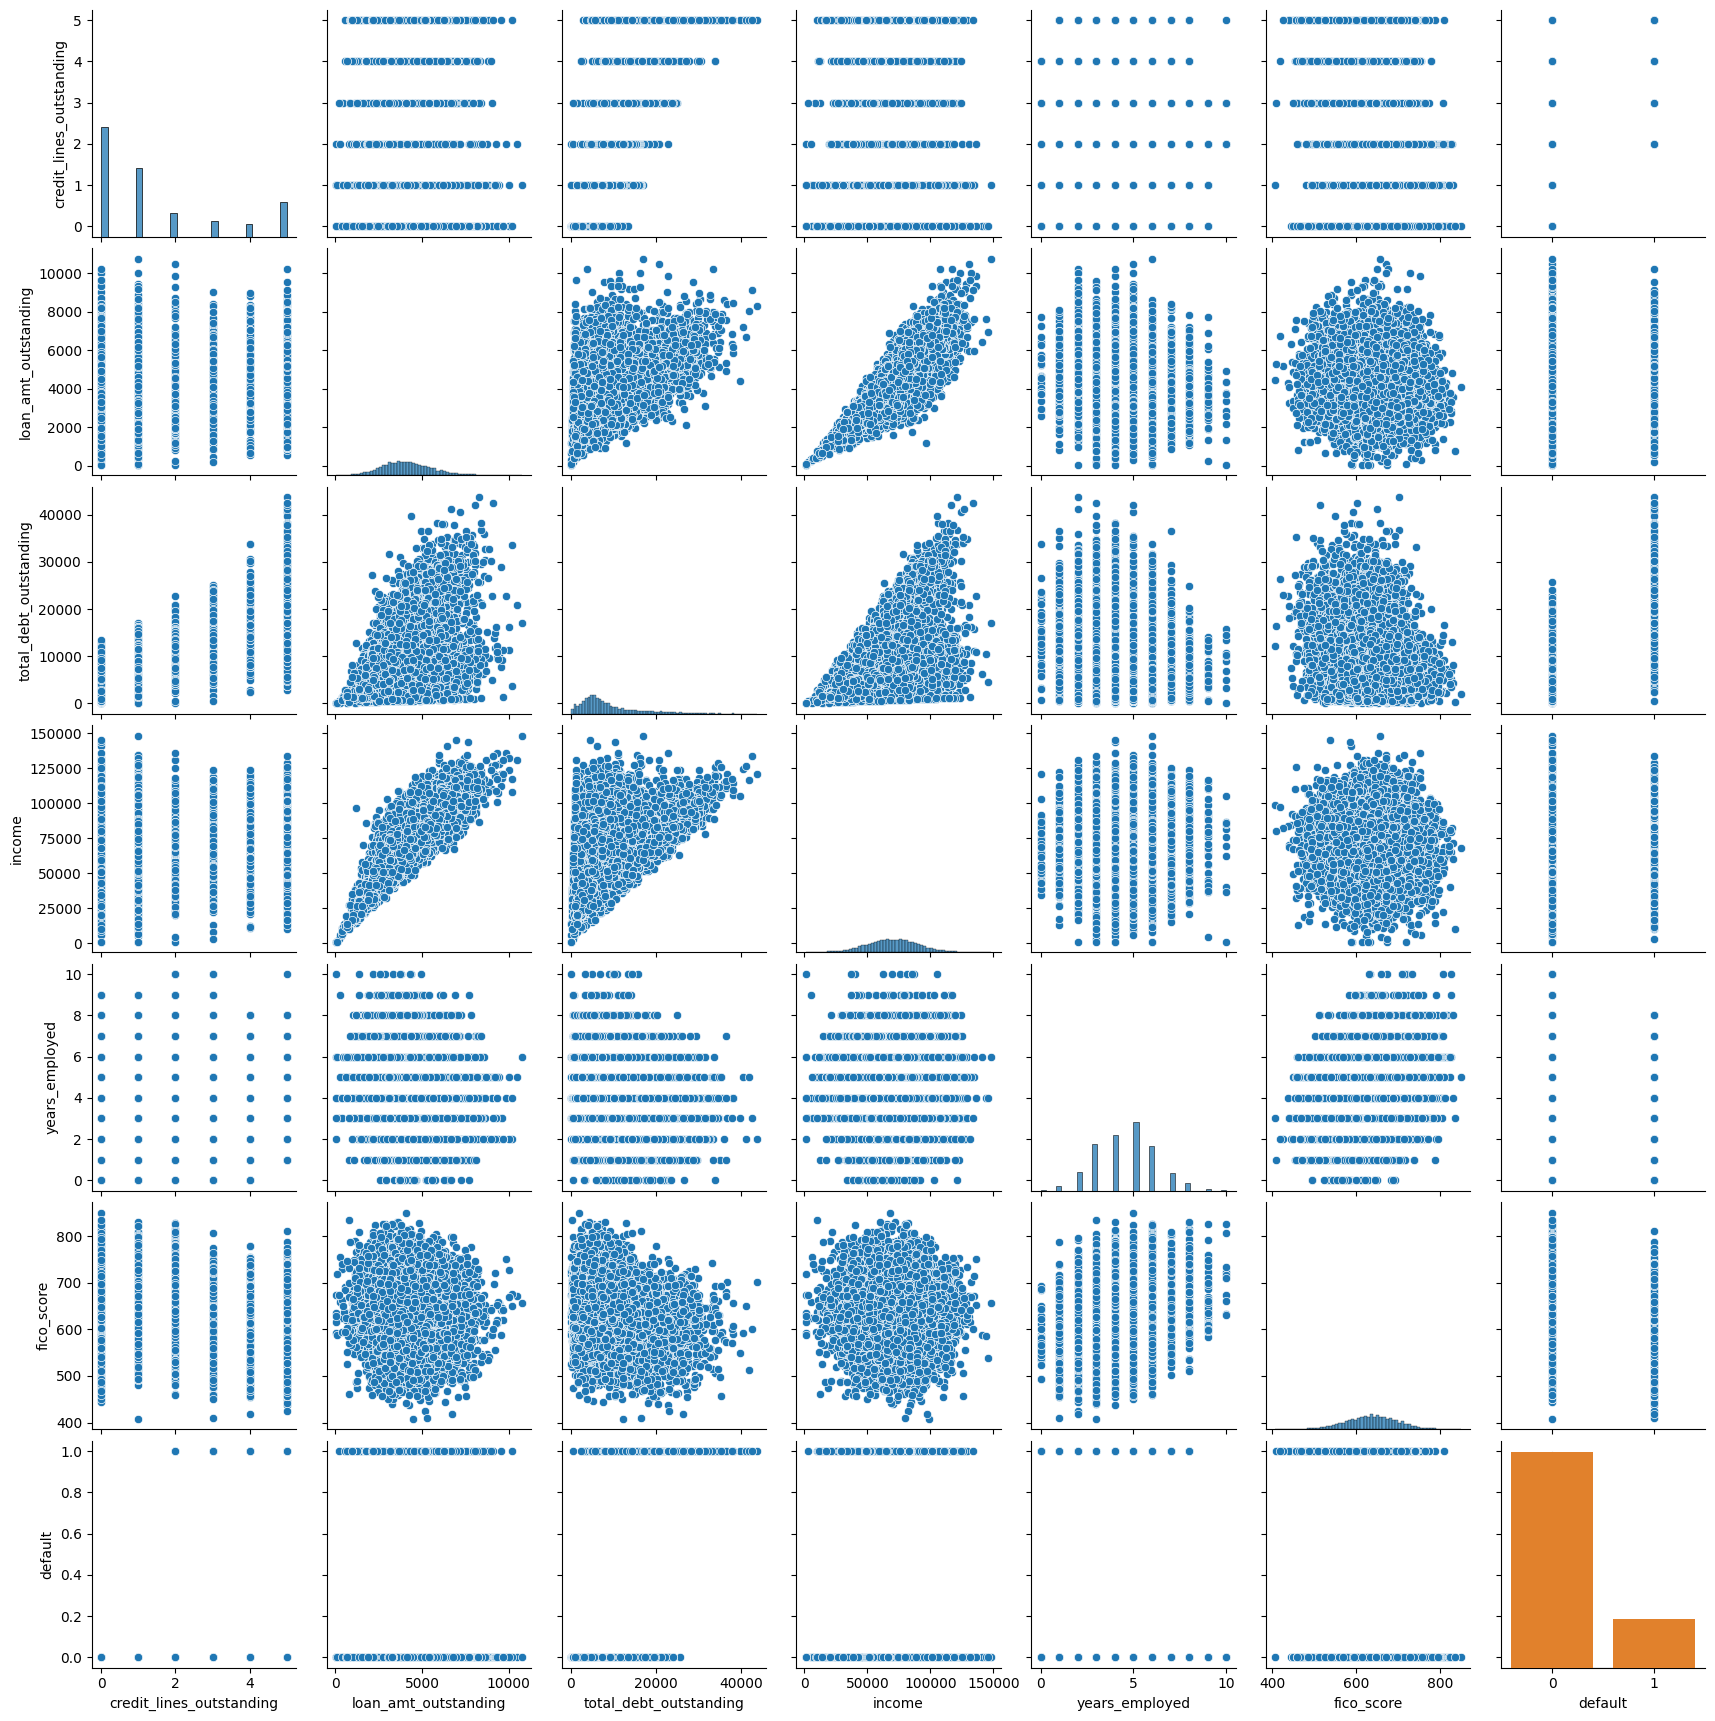

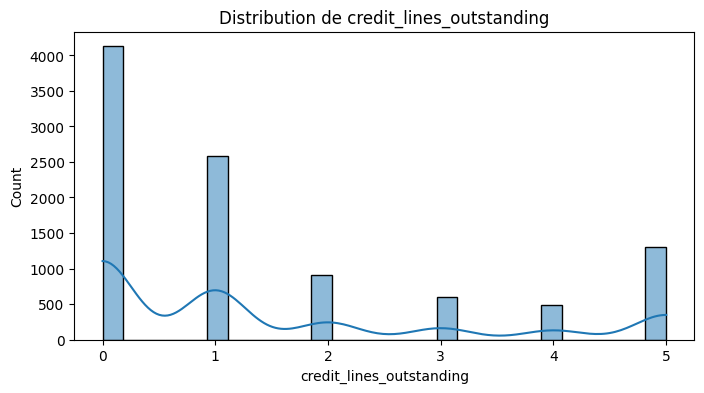

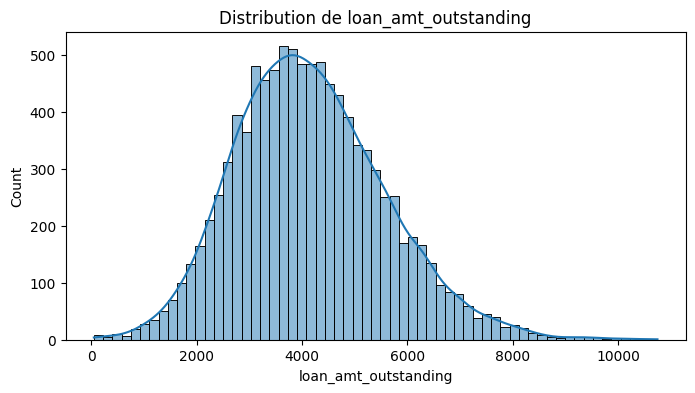

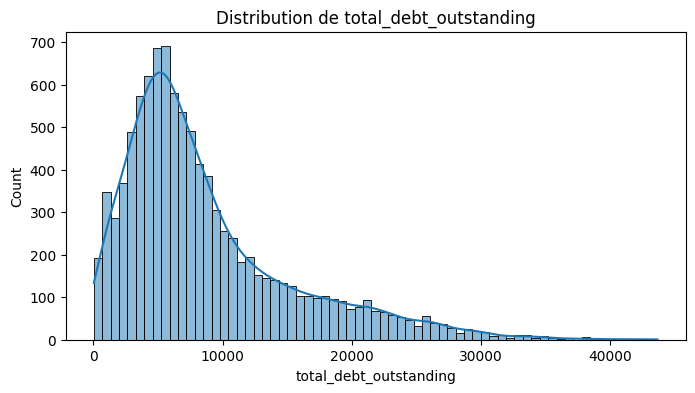

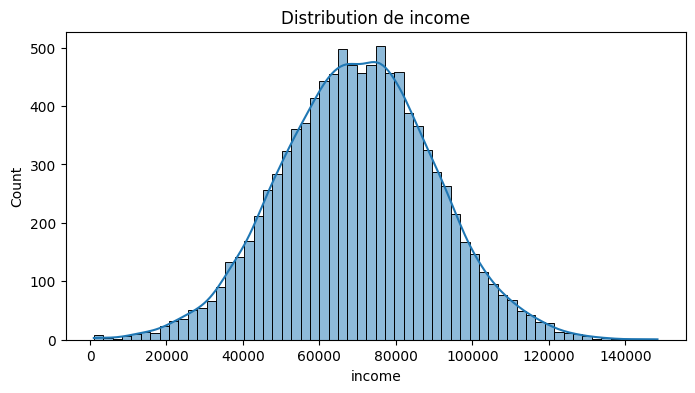

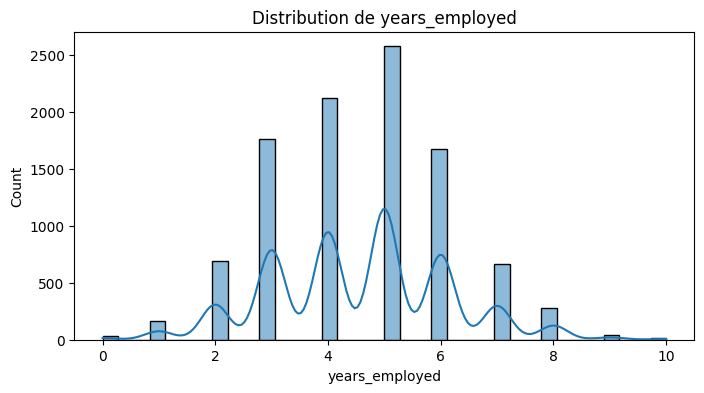

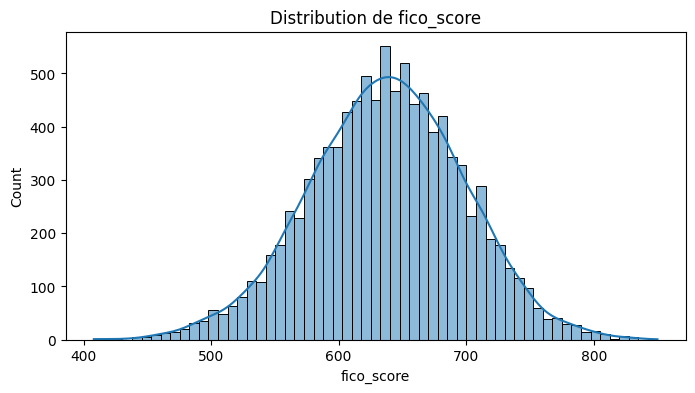

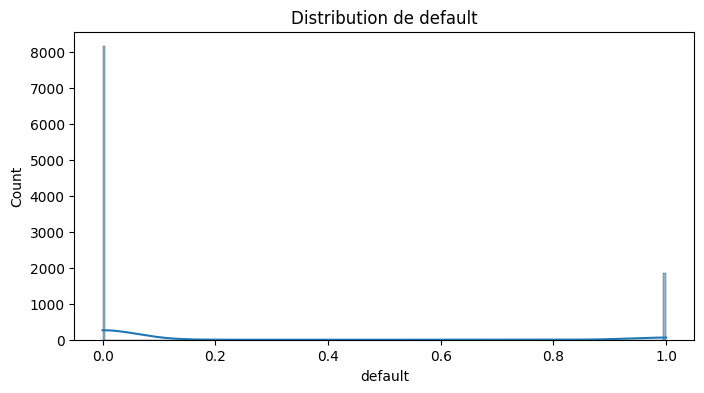

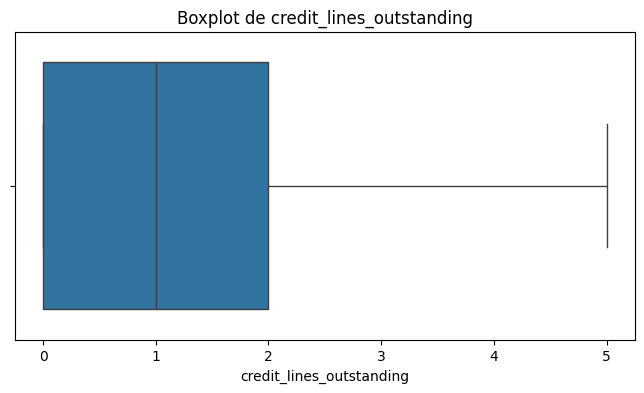

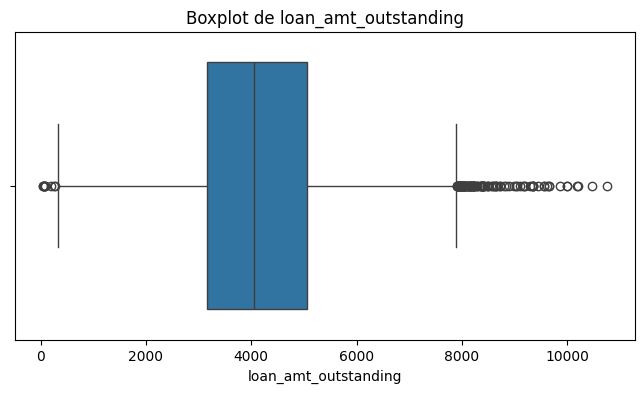

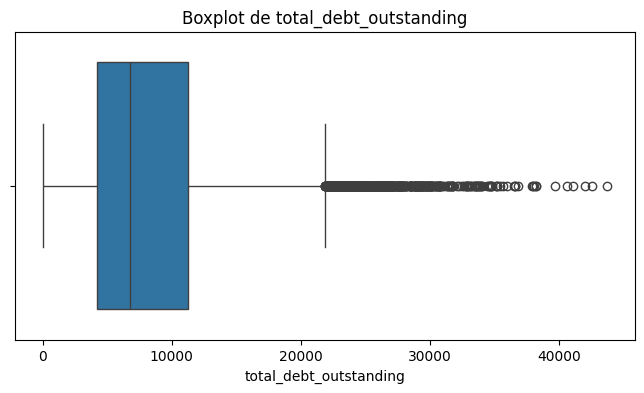

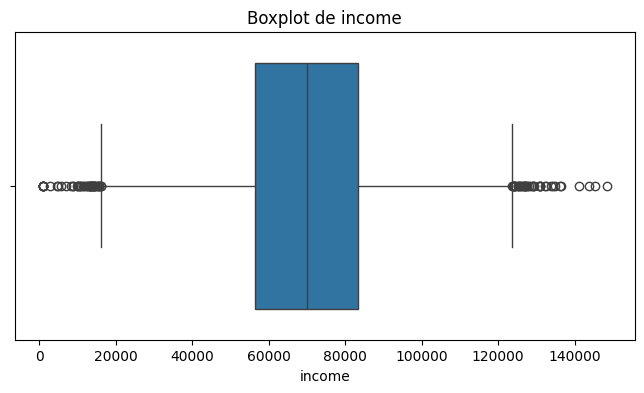

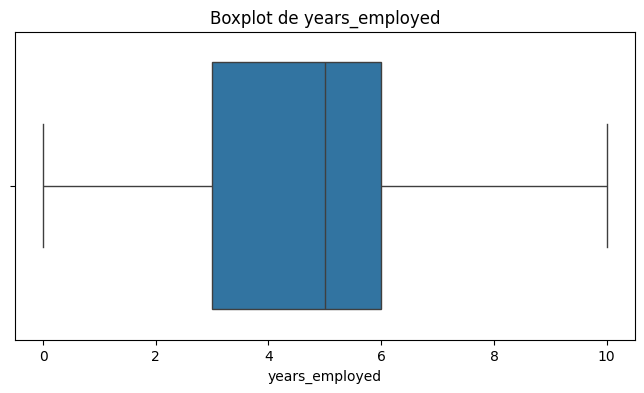

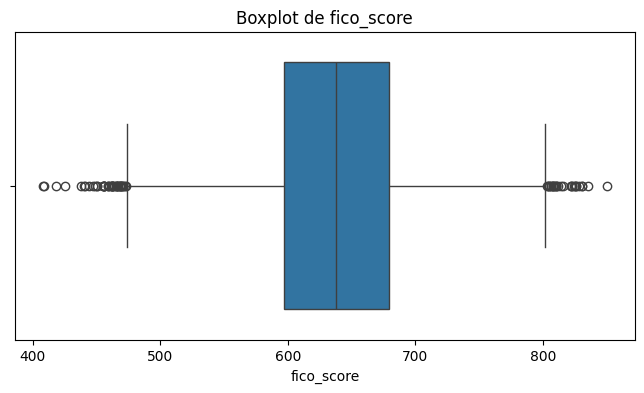

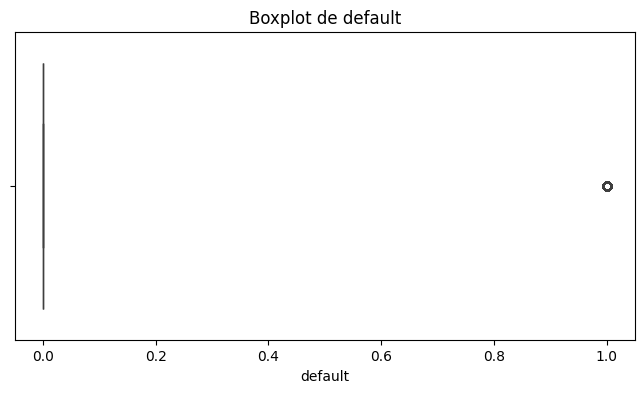

In [188]:

data_net= data.drop(columns=['customer_id'])


# Matrice de corrélation

plt.figure(figsize=(12, 10))   
sns.heatmap(data_net.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation') 
plt.show()
# Liste des corrélations > 0,8
correlation_matrix = data_net.corr()
high_correlation = correlation_matrix[correlation_matrix.abs()> 0.75]
print("Correlations supérieures à 0,75 :")
display(high_correlation)
# Matrice graphique de corrélation
sns.pairplot(data_net)
# Analyse de la distribution de la variable cible 'default'
sns.countplot(x='default', data=data_net)

# Visualisation de la distribution des variables numériques
#numeric_columns = data.select_dtypes(include=[np.number]).columns
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution de {column}')
    plt.show()

# Analyse des outliers avec des boxplots
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_net[column])
    plt.title(f'Boxplot de {column}')
    plt.show()



In [189]:
#check
print(type(data_net.corr()))
display(data_net.corr().size)
display(data_net.corr().shape)  


<class 'pandas.DataFrame'>


49

(7, 7)

# Investigation Data Leakage\nOn vérifie si certaines features encodent directement la variable cible `default`.\nUn taux de défaut très différent selon les modalités d'une feature = suspicion de leakage.

=== Crosstab credit_lines_outstanding vs default (taux par modalité) ===


default,0,1
credit_lines_outstanding,,
0,1.000000,0.000000
1,1.000000,0.000000
2,0.992239,0.007761
3,0.771285,0.228715
4,0.148760,0.851240
5,0.001542,0.998458



=== Effectifs credit_lines_outstanding vs default ===


default,0,1
credit_lines_outstanding,,
0,4128,0
1,2590,0
2,895,7
3,462,137
4,72,412
5,2,1295


C:\Users\Bernard\AppData\Local\Temp\ipykernel_23624\1029514015.py:14: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  default_rate.plot(kind='bar', ax=axes[0], color='coral')
C:\Users\Bernard\AppData\Local\Temp\ipykernel_23624\1029514015.py:21: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  default_rate_loan.plot(kind='bar', ax=axes[1], color='steelblue')


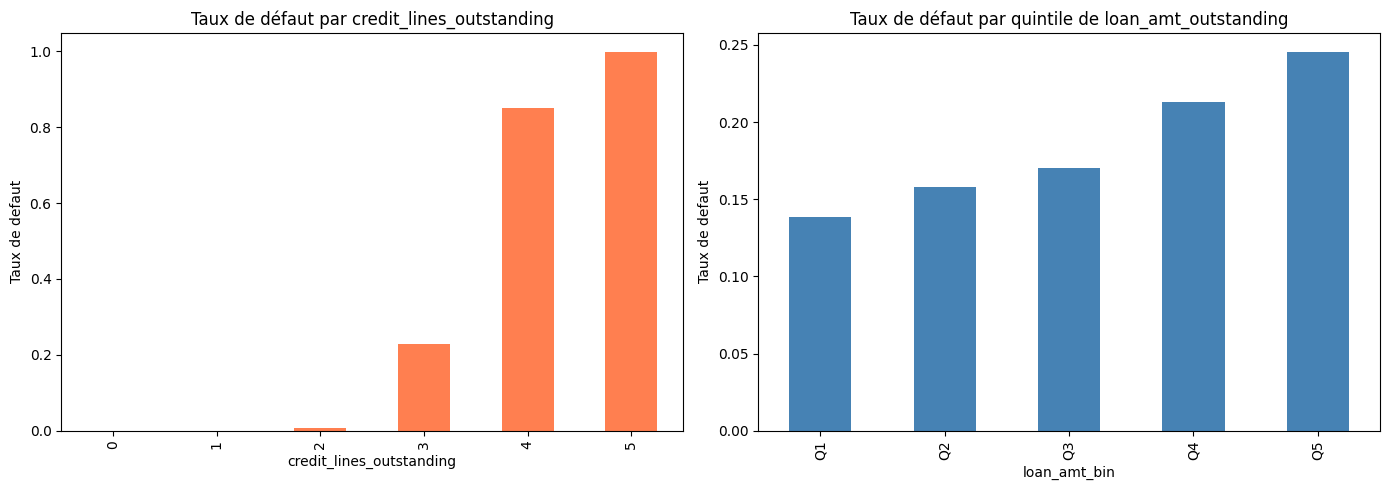


=== Conclusion ===
Si credit_lines_outstanding >= 3 implique default ~ 100%, c'est un data leaker (fuite de données).


In [190]:
# Investigation du leakage : relation entre credit_lines_outstanding et default
print("=== Crosstab credit_lines_outstanding vs default (taux par modalité) ===")
ct = pd.crosstab(data['credit_lines_outstanding'], data['default'], normalize='index')
display(ct)

print("\n=== Effectifs credit_lines_outstanding vs default ===")
display(pd.crosstab(data['credit_lines_outstanding'], data['default']))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de défaut par credit_lines_outstanding
default_rate = data.groupby('credit_lines_outstanding')['default'].mean()
default_rate.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Taux de défaut par credit_lines_outstanding')
axes[0].set_ylabel('Taux de defaut')

# Taux de defaut par tranche de loan_amt_outstanding
data['loan_amt_bin'] = pd.qcut(data['loan_amt_outstanding'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
default_rate_loan = data.groupby('loan_amt_bin')['default'].mean()
default_rate_loan.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Taux de défaut par quintile de loan_amt_outstanding')
axes[1].set_ylabel('Taux de defaut')

plt.tight_layout()
plt.show()

# Nettoyage colonne temporaire
data.drop(columns=['loan_amt_bin'], inplace=True)

print("\n=== Conclusion ===")
print("Si credit_lines_outstanding >= 3 implique default ~ 100%, c'est un data leaker (fuite de données).")

# Définition FICO score:
* Le score FICO est un indicateur de solvabilité largement utilisé aux États-Unis pour évaluer le risque de crédit d’un emprunteur. Il permet aux établissements financiers d’estimer la probabilité qu’une personne rembourse correctement ses dettes.
Ce score est généralement compris entre 300 et 850. Plus il est élevé, plus le profil de crédit est considéré comme fiable. Il est notamment pris en compte lors de demandes de carte bancaire, de prêt automobile, de crédit immobilier ou de prêt personnel.
Le calcul du score FICO repose sur plusieurs éléments du dossier de crédit, parmi lesquels figurent l’historique des paiements, le niveau d’endettement, l’ancienneté du crédit, le nombre de nouvelles demandes de crédit ainsi que la diversité des types de crédit utilisés.
À titre indicatif, un score supérieur à 800 est considéré comme excellent, entre 740 et 799 comme très bon, entre 670 et 739 comme bon, entre 580 et 669 comme moyen, et inférieur à 580 comme faible.*

In [191]:
# Paradoxe: le fixo_score est ici peu corréler au défault 

In [192]:
# Suppression de la colonne 'default' 

data_vif= data_net.drop(columns=['default'])

print(data_vif.head())

   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0           5221.545193             3915.471226   
1                         5           1958.928726             8228.752520   
2                         0           3363.009259             2027.830850   
3                         0           4766.648001             2501.730397   
4                         1           1345.827718             1768.826187   

        income  years_employed  fico_score  
0  78039.38546               5         605  
1  26648.43525               2         572  
2  65866.71246               4         602  
3  74356.88347               5         612  
4  23448.32631               6         631  


In [193]:
# Analyse VIF   
# Calcul du VIF pour chaque variable
from statsmodels.stats.outliers_influence import variance_inflation_factor   
vif_values = [variance_inflation_factor(data_vif.values, i) for i in range(data_vif.shape[1])]
for i in range(len(vif_values)):
    print(f"VIF for {data_vif.columns[i]}: {vif_values[i]}")     

VIF for credit_lines_outstanding: 10.9488455880746
VIF for loan_amt_outstanding: 35.08803552231979
VIF for total_debt_outstanding: 21.937163377951418
VIF for income: 59.93081187684781
VIF for years_employed: 11.896744233503542
VIF for fico_score: 22.404741558573658


In [194]:
# Vérifier la relation entre credit_lines_outstanding et default
display(pd.crosstab(data['credit_lines_outstanding'], data['default'], normalize='index'))





default,0,1
credit_lines_outstanding,,
0,1.000000,0.000000
1,1.000000,0.000000
2,0.992239,0.007761
3,0.771285,0.228715
4,0.148760,0.851240
5,0.001542,0.998458


C:\Users\Bernard\AppData\Local\Temp\ipykernel_23624\1864426862.py:8: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = ct[1].plot(kind='line', marker='o', linewidth=2)


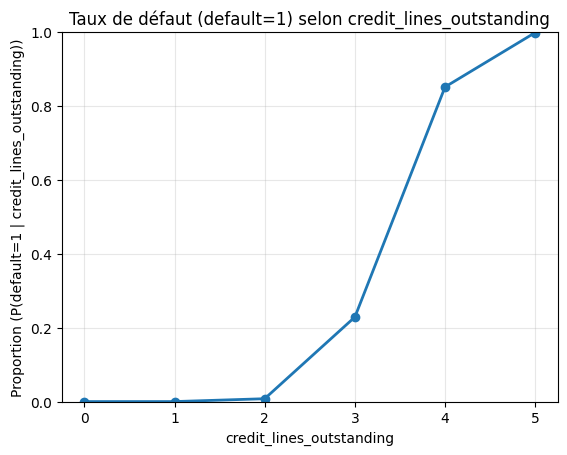

In [195]:

ct = pd.crosstab(
    data['credit_lines_outstanding'],
    data['default'],
    normalize='index'
)

# Courbe du taux de défaut (colonne 1)
ax = ct[1].plot(kind='line', marker='o', linewidth=2)

ax.set_title("Taux de défaut (default=1) selon credit_lines_outstanding")
ax.set_xlabel("credit_lines_outstanding")
ax.set_ylabel("Proportion (P(default=1 | credit_lines_outstanding))")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.show()




In [196]:
# Préparation des données pour la modélisation
# CORRECTION : On retire credit_lines_outstanding (data leaker confirmé par le crosstab)
# et total_debt_outstanding (forte multicolinéarité)
X = data_net.drop(columns=['default', 'total_debt_outstanding', 'credit_lines_outstanding'])
y = data_net['default']

print("Features retenues :", list(X.columns))
display(X.shape)
display(y.shape)
display(y.value_counts(normalize=True))
print(X.head())

Features retenues : ['loan_amt_outstanding', 'income', 'years_employed', 'fico_score']


(10000, 4)

(10000,)

default
0    0.8149
1    0.1851
Name: proportion, dtype: float64

   loan_amt_outstanding       income  years_employed  fico_score
0           5221.545193  78039.38546               5         605
1           1958.928726  26648.43525               2         572
2           3363.009259  65866.71246               4         602
3           4766.648001  74356.88347               5         612
4           1345.827718  23448.32631               6         631


In [197]:
# Génaréation des données d'entraînement et de test / val sera traité par CV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seeds)

# ====================================
# [FIX] Compatibilite pandas 2.x / joblib (GridSearchCV n_jobs=-1)
# ====================================
# Depuis pandas 2.x, l'option 'future.infer_string' peut etre activee par defaut
# dans certains environnements (Jupyter, IPython). Quand elle est active, les noms
# de colonnes et les donnees textuelles utilisent le type StringDtype (PyArrow ou
# Python) au lieu du type classique 'object' (numpy).
#
# Or GridSearchCV avec n_jobs=-1 utilise joblib pour paralleliser les fits sur
# plusieurs processus. Joblib serialise (pickle) les donnees pour les envoyer aux
# workers. Le type StringDtype n'est pas correctement deserialisable par les workers,
# ce qui provoque l'erreur :
#   BrokenProcessPool: A task has failed to un-serialize.
#   NotImplementedError: (<StringDtype(storage='python', na_value=nan)>, ...)
#
# Solution en 2 etapes :
#   1. Desactiver future.infer_string pour forcer les types classiques
#   2. Convertir X_train/X_test/y_train/y_test en arrays numpy purs
#      (plus aucune dependance aux types internes de pandas)
#
# On sauvegarde les noms de colonnes dans 'feature_names' (liste Python)
# avant la conversion, pour pouvoir les reutiliser dans les graphiques
# (feature importance, SMOTE, etc.).
# ====================================

# [FIX] Desactivation de future.infer_string pour compatibilite joblib/GridSearchCV
pd.set_option('future.infer_string', False)

# [FIX] Conversion en arrays numpy pour eviter les erreurs de serialisation joblib
feature_names = X.columns.tolist()
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

display(X_train.shape, y_train.shape,  X_test.shape, y_test.shape)

# [FIX] Affichage numpy
print("X_train (5 premieres lignes):")
print(X_train[:5])
print("y_train (5 premieres valeurs):")
print(y_train[:5]) 

(8000, 4)

(8000,)

(2000, 4)

(2000,)

X_train (5 premieres lignes):
[[5.18388884e+03 7.43120397e+04 3.00000000e+00 5.50000000e+02]
 [2.83106254e+03 7.10767307e+04 5.00000000e+00 6.60000000e+02]
 [5.80185172e+03 7.16475337e+04 3.00000000e+00 6.36000000e+02]
 [2.31391068e+03 5.26100827e+04 6.00000000e+00 7.45000000e+02]
 [6.06440051e+03 1.14497052e+05 8.00000000e+00 6.77000000e+02]]
y_train (5 premieres valeurs):
[1 0 1 0 0]



  Logistic Regression
Best params: {'model__C': 0.1}
Best CV Recall: 0.7664

--- Comparaison Train vs Test (détection de l'overfitting) ---
  Train Accuracy : 0.6711
  Test  Accuracy : 0.6685
  Train Recall   : 0.7691
  Test  Recall   : 0.7595
  Train F1       : 0.4640
  Test  F1       : 0.4588
  >> OK : écarts train-test raisonnables

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.92      0.65      0.76      1630
           1       0.33      0.76      0.46       370

    accuracy                           0.67      2000
   macro avg       0.63      0.70      0.61      2000
weighted avg       0.81      0.67      0.71      2000



c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


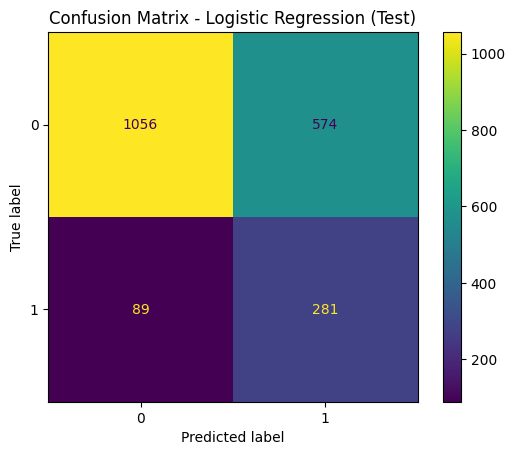

2026/04/03 16:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 16:26:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Random Forest
Best params: {'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Recall: 0.7515

--- Comparaison Train vs Test (détection de l'overfitting) ---
  Train Accuracy : 0.6819
  Test  Accuracy : 0.6690
  Train Recall   : 0.7576
  Test  Recall   : 0.7162
  Train F1       : 0.4686
  Test  F1       : 0.4446
  >> OK : écarts train-test raisonnables

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1630
           1       0.32      0.72      0.44       370

    accuracy                           0.67      2000
   macro avg       0.62      0.69      0.60      2000
weighted avg       0.80      0.67      0.71      2000



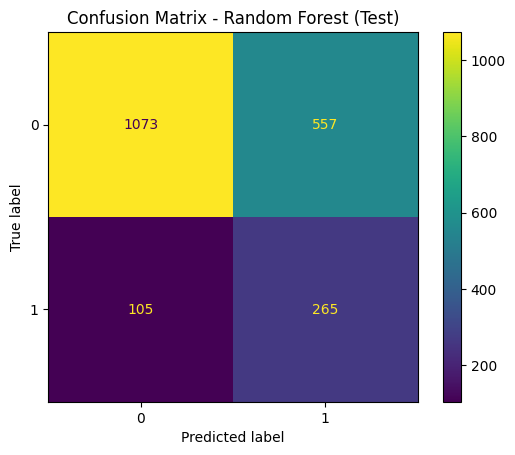

2026/04/03 16:26:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 16:26:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  XGBoost
Best params: {'model__max_depth': 3, 'model__n_estimators': 10, 'model__scale_pos_weight': 5.4}
Best CV Recall: 0.7475

--- Comparaison Train vs Test (détection de l'overfitting) ---
  Train Accuracy : 0.6907
  Test  Accuracy : 0.6730
  Train Recall   : 0.7589
  Test  Recall   : 0.7081
  Train F1       : 0.4761
  Test  F1       : 0.4448
  >> ALERTE : écart train-test important (acc gap=0.0177, recall gap=0.0508)

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1630
           1       0.32      0.71      0.44       370

    accuracy                           0.67      2000
   macro avg       0.62      0.69      0.61      2000
weighted avg       0.80      0.67      0.71      2000



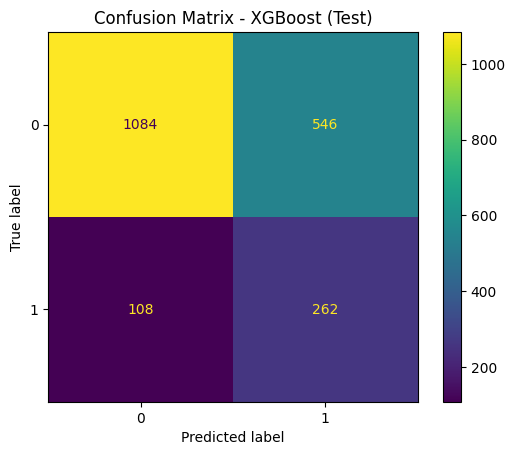

2026/04/03 16:26:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 16:26:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  MLP Classifier
Best params: {'model__hidden_layer_sizes': (80, 60, 6)}
Best CV Recall: 0.2782

--- Comparaison Train vs Test (détection de l'overfitting) ---
  Train Accuracy : 0.8505
  Test  Accuracy : 0.8240
  Train Recall   : 0.3261
  Test  Recall   : 0.2216
  Train F1       : 0.4468
  Test  F1       : 0.3178
  >> ALERTE : écart train-test important (acc gap=0.0265, recall gap=0.1045)

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1630
           1       0.56      0.22      0.32       370

    accuracy                           0.82      2000
   macro avg       0.70      0.59      0.61      2000
weighted avg       0.79      0.82      0.79      2000



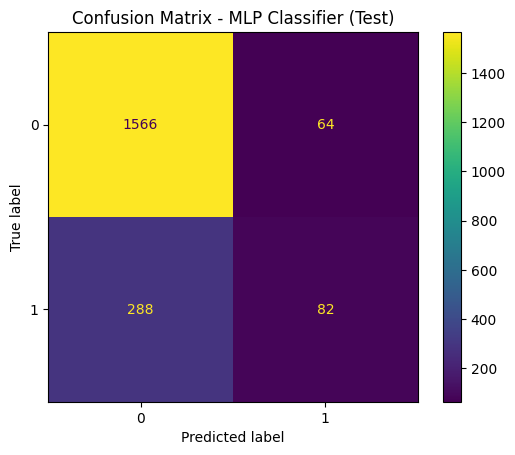

2026/04/03 16:27:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 16:27:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



TOP 15 configs (tous modèles) :
         model_name  rank_test_score  mean_test_score  std_test_score                                                                             params
Logistic Regression                1         0.766389        0.012216                                                                  {'model__C': 0.1}
      Random Forest                1         0.751520        0.013602                                {'model__max_depth': 3, 'model__n_estimators': 100}
            XGBoost                1         0.747472        0.013657 {'model__max_depth': 3, 'model__n_estimators': 10, 'model__scale_pos_weight': 5.4}
     MLP Classifier                1         0.278187        0.027709                                         {'model__hidden_layer_sizes': (80, 60, 6)}
Logistic Regression                2         0.766387        0.012267                                                                 {'model__C': 0.01}
Logistic Regression                2         0.76

In [198]:
# Création du pipeline de modélisation
var_smote= False
models = {
    "Logistic Regression": LogisticRegression(
        solver="saga",
        penalty="l1",
        max_iter=5000,
        random_state=seeds, class_weight="balanced" if var_smote else {0: 1.0, 1: 5.4}
    ),
    "Random Forest": RandomForestClassifier(
        random_state=seeds,
        class_weight="balanced" if var_smote else {  0: 1.0, 1: 5.4 }
    ),
    "XGBoost": XGBClassifier(
        random_state=seeds,
        eval_metric="logloss",scale_pos_weight= 1 if  var_smote else 5.4
    ),  
    "MLP Classifier": MLPClassifier(
        random_state=seeds,
        max_iter=500,
    )
}

gridsearch_params = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 5]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 10],
        "model__max_depth": [3, 5, 15]
    },
    "XGBoost": {
        "model__n_estimators": [50, 10, 20],
        "model__max_depth": [3, 5, 15],
        "model__scale_pos_weight": [5.4]  # ratio classes 0/1 ~ 0.815/0.185 ~ 5.4
    },
    "MLP Classifier": {
        "model__hidden_layer_sizes": [(32, 48), (80, 60, 6)]
    }
}

# ====================================
#  Boucle GridSearchCV + évaluation
# ====================================
all_results = []
best_models = {}

stratifiedkfold = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds)

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=gridsearch_params[name],
        cv=stratifiedkfold,
        scoring="recall",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Predictions train et test
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV Recall: {grid.best_score_:.4f}")

    # Comparaison train vs test pour detecter overfitting
    print(f"\n--- Comparaison Train vs Test (détection de l'overfitting) ---")
    print(f"  Train Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"  Test  Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"  Train Recall   : {recall_score(y_train, y_pred_train):.4f}")
    print(f"  Test  Recall   : {recall_score(y_test, y_pred_test):.4f}")
    print(f"  Train F1       : {f1_score(y_train, y_pred_train):.4f}")
    print(f"  Test  F1       : {f1_score(y_test, y_pred_test):.4f}")

    gap_acc = accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test)
    gap_recall = recall_score(y_train, y_pred_train) - recall_score(y_test, y_pred_test)
    if gap_acc > 0.05 or gap_recall > 0.05:
        print(f"  >> ALERTE : écart train-test important (acc gap={gap_acc:.4f}, recall gap={gap_recall:.4f})")
    else:
        print(f"  >> OK : écarts train-test raisonnables")

    print(f"\n--- Classification Report (Test) ---")
    print(classification_report(y_test, y_pred_test))

    # Matrice de confusion test
    fig_cm, ax_cm = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax_cm)
    ax_cm.set_title(f"Confusion Matrix - {name} (Test)")
    plt.show()

    # [MLF0] Tracking MLflow pour chaque modèle
    with mlflow.start_run(run_name=f"{name}"):
        # Log des meilleurs hyperparamètres
        mlflow.log_params(grid.best_params_)
        mlflow.log_param("model_type", name)
        mlflow.log_param("cv_folds", 5)
        mlflow.log_param("scoring", "recall")
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", seeds)
        mlflow.set_tag("smote", "false")
        mlflow.set_tag("features", str(list(X.columns)))

        # Métriques de validation croisée
        mlflow.log_metric("best_cv_recall", grid.best_score_)

        # Métriques train
        mlflow.log_metric("train_accuracy", accuracy_score(y_train, y_pred_train))
        mlflow.log_metric("train_recall", recall_score(y_train, y_pred_train))
        mlflow.log_metric("train_f1", f1_score(y_train, y_pred_train))

        # Métriques test
        mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_pred_test))
        mlflow.log_metric("test_recall", recall_score(y_test, y_pred_test))
        mlflow.log_metric("test_f1", f1_score(y_test, y_pred_test))
        mlflow.log_metric("test_precision", precision_score(y_test, y_pred_test))

        # AUC-ROC si predict_proba disponible
        try:
            y_proba = best_model.predict_proba(X_test)[:, 1]
            mlflow.log_metric("test_auc_roc", roc_auc_score(y_test, y_proba))
        except AttributeError:
            pass

        # Écarts overfitting
        mlflow.log_metric("gap_accuracy", gap_acc)
        mlflow.log_metric("gap_recall", gap_recall)

        # Sauvegarde du modèle (pipeline complet)
        mlflow.sklearn.log_model(best_model, artifact_path="model")

        # Sauvegarde de la matrice de confusion
        fig_cm_log, ax_cm_log = plt.subplots()
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax_cm_log)
        ax_cm_log.set_title(f"Confusion Matrix - {name} (Test)")
        cm_path = f"confusion_matrix_{name.replace(' ', '_')}.png"
        fig_cm_log.savefig(cm_path, bbox_inches='tight')
        mlflow.log_artifact(cm_path)
        plt.close(fig_cm_log)
        os.remove(cm_path)

    # Stockage cv_results
    cv_df = pd.DataFrame(grid.cv_results_)
    cv_df["model_name"] = name
    all_results.append(cv_df)

# ====================================
#  Tableau global : meilleures configurations
# ====================================
results_df = pd.concat(all_results, ignore_index=True)
top = (
    results_df[["model_name", "rank_test_score", "mean_test_score", "std_test_score", "params"]]
    .sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])
    .head(15)
)
print("\nTOP 15 configs (tous modèles) :")
print(top.to_string(index=False))

# Feature Importance & Learning Curves\nAnalyse de l'importance des features pour détecter si une seule variable domine (signe de leakage résiduel).\nLes learning curves permettent de visualiser l'overfitting : si le score train reste très haut tandis que le score de validation stagne bas, le modèle overfitte.

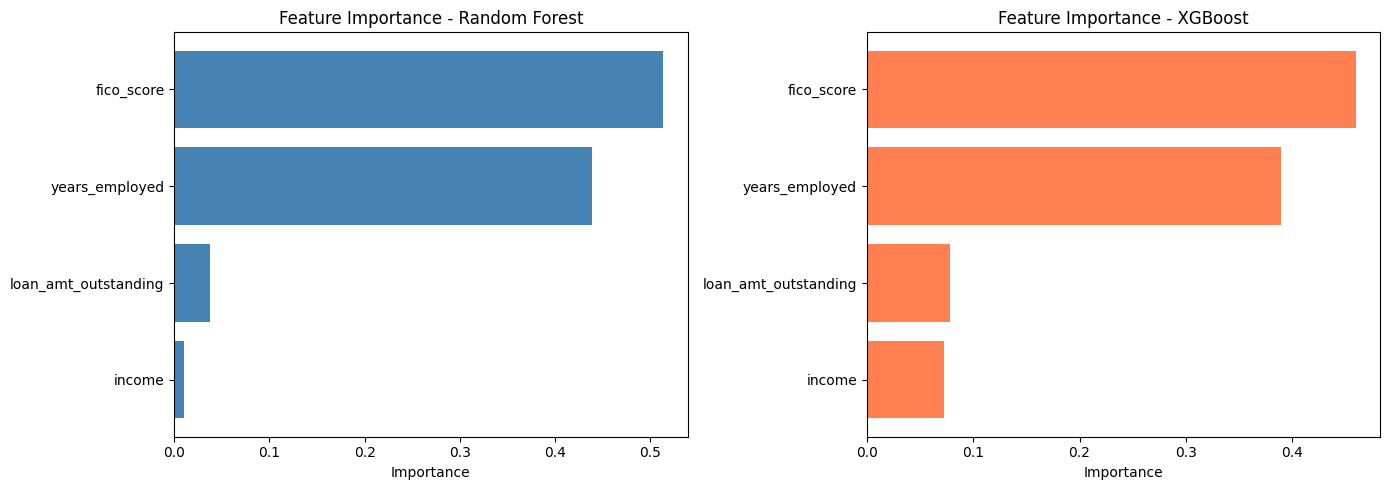


Logistic Regression - Coefficients absolus (features scalées) :
income                  0.357739
loan_amt_outstanding    0.478017
years_employed          0.596829
fico_score              0.789815
dtype: float64

>> Random Forest: importance répartie (max = 51.4%), pas de leakage évident

>> XGBoost: importance répartie (max = 45.9%), pas de leakage évident


In [199]:
# ====================================
#  Feature Importance
# ====================================
feature_names = X.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
if "Random Forest" in best_models:
    rf_model = best_models["Random Forest"].named_steps['model']
    importances_rf = rf_model.feature_importances_
    idx_rf = np.argsort(importances_rf)
    axes[0].barh(feature_names[idx_rf], importances_rf[idx_rf], color='steelblue')
    axes[0].set_title("Feature Importance - Random Forest")
    axes[0].set_xlabel("Importance")

# XGBoost feature importance
if "XGBoost" in best_models:
    xgb_model = best_models["XGBoost"].named_steps['model']
    importances_xgb = xgb_model.feature_importances_
    idx_xgb = np.argsort(importances_xgb)
    axes[1].barh(feature_names[idx_xgb], importances_xgb[idx_xgb], color='coral')
    axes[1].set_title("Feature Importance - XGBoost")
    axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Logistic Regression coefficients
if "Logistic Regression" in best_models:
    lr_model = best_models["Logistic Regression"].named_steps['model']
    coefs = pd.Series(lr_model.coef_[0], index=feature_names).abs().sort_values()
    print("\nLogistic Regression - Coefficients absolus (features scalées) :")
    print(coefs)

# Verification : une feature concentre-t-elle > 80% de l'importance ?
for name_model in ["Random Forest", "XGBoost"]:
    if name_model in best_models:
        imp = best_models[name_model].named_steps['model'].feature_importances_
        max_imp = imp.max()
        if max_imp > 0.80:
            print(f"\n>> ALERTE {name_model}: une feature concentre {max_imp:.1%} de l'importance (leakage probable)")
        else:
            print(f"\n>> {name_model}: importance répartie (max = {max_imp:.1%}), pas de leakage évident")

# [MLF0] Sauvegarde des feature importances comme artifact MLflow
fig.savefig("feature_importances.png", bbox_inches='tight')
with mlflow.start_run(run_name="Feature_Importances"):
    mlflow.log_artifact("feature_importances.png")
    mlflow.set_tag("artifact_type", "feature_importance")
os.remove("feature_importances.png")

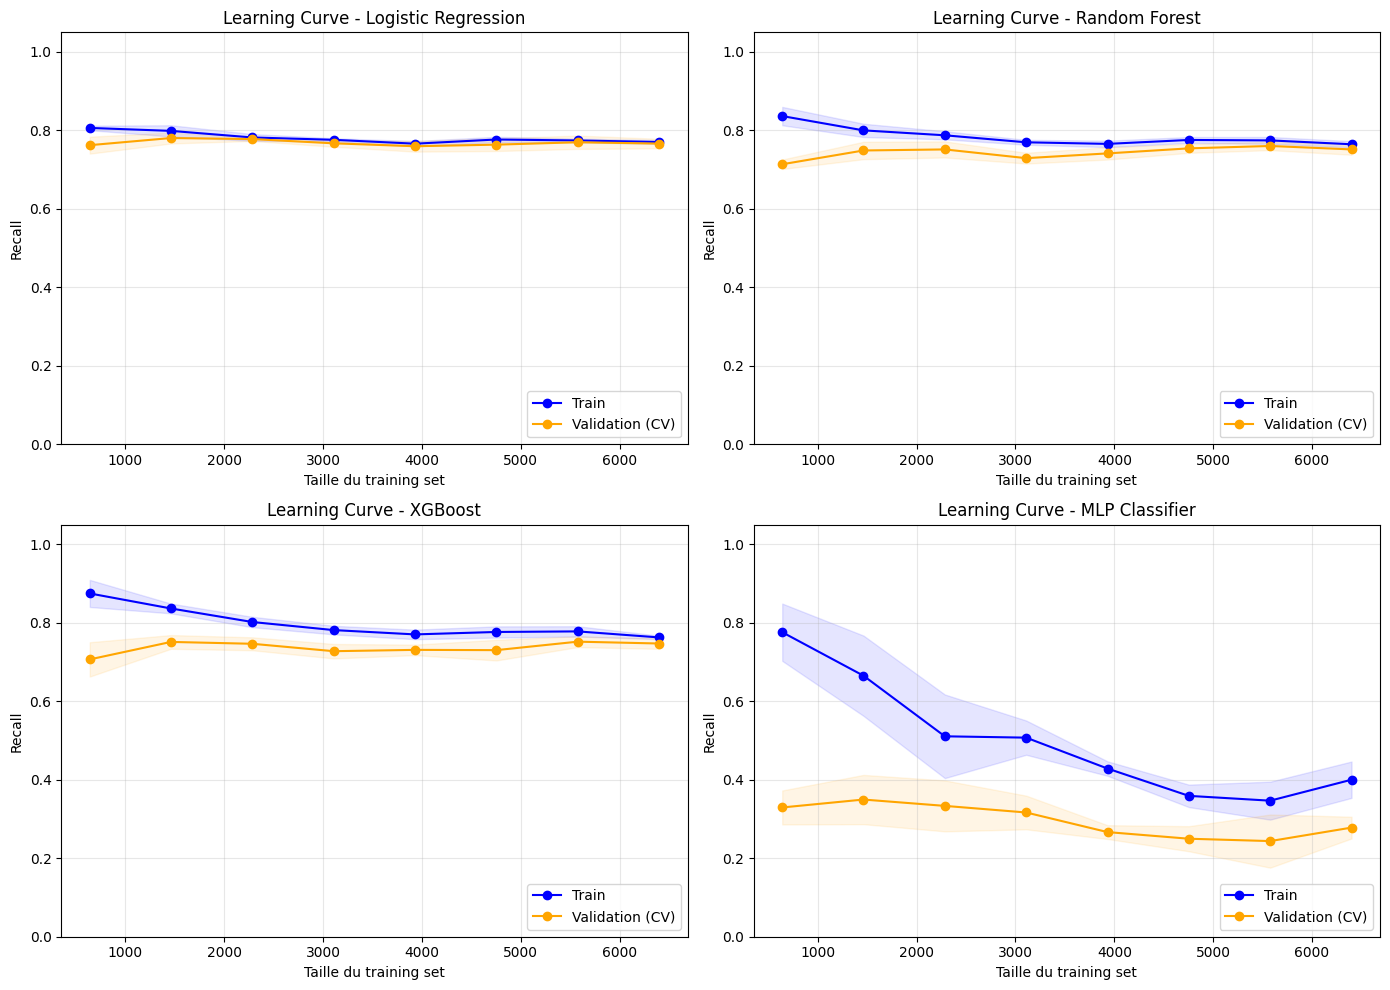

Si train >> validation avec un écart constant = overfitting
Si les deux courbes convergent vers un score élevé = bon modèle
Si les deux courbes sont basses = underfitting


In [200]:
# ====================================
#  Learning Curves
# ====================================
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model_pipeline) in enumerate(best_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model_pipeline, X_train, y_train,
        cv=stratifiedkfold,
        scoring='recall',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax = axes[idx]
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation (CV)')
    ax.set_title(f'Learning Curve - {name}')
    ax.set_xlabel('Taille du training set')
    ax.set_ylabel('Recall')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Si train >> validation avec un écart constant = overfitting")
print("Si les deux courbes convergent vers un score élevé = bon modèle")
print("Si les deux courbes sont basses = underfitting")

# [MLF0] Sauvegarde des learning curves comme artifact MLflow
fig.savefig("learning_curves.png", bbox_inches='tight')
with mlflow.start_run(run_name="Learning_Curves"):
    mlflow.log_artifact("learning_curves.png")
    mlflow.set_tag("artifact_type", "learning_curve")
os.remove("learning_curves.png")

# Test de robustesse avec SMOTE
**SMOTE** (Synthetic Minority Over-sampling Technique) génère des échantillons synthétiques de la classe minoritaire (`default=1`) par interpolation entre les k plus proches voisins réels.
SMOTE crée des échantillons **dans le même espace** que les données d'entraînement, ce qui permet :
1. D'équilibrer les classes pour l'entrainement
2. De tester le modele sur des défauts synthétiques réalistes
3. De vérifier que le modèle distingue bien les vrais non-defauts des faux defauts generes

**Important** : SMOTE s'applique UNIQUEMENT sur le train set (jamais sur le test) pour éviter tout leakage.

=== Avant SMOTE (train) ===
  Total : 8000
  Default=0 : 6519 (81.5%)
  Default=1 : 1481 (18.5%)

=== Apres SMOTE (train) ===
  Total : 13038
  Default=0 : 6519 (50.0%)
  Default=1 : 6519 (50.0%)

  => 5038 échantillons default=1 générés par SMOTE


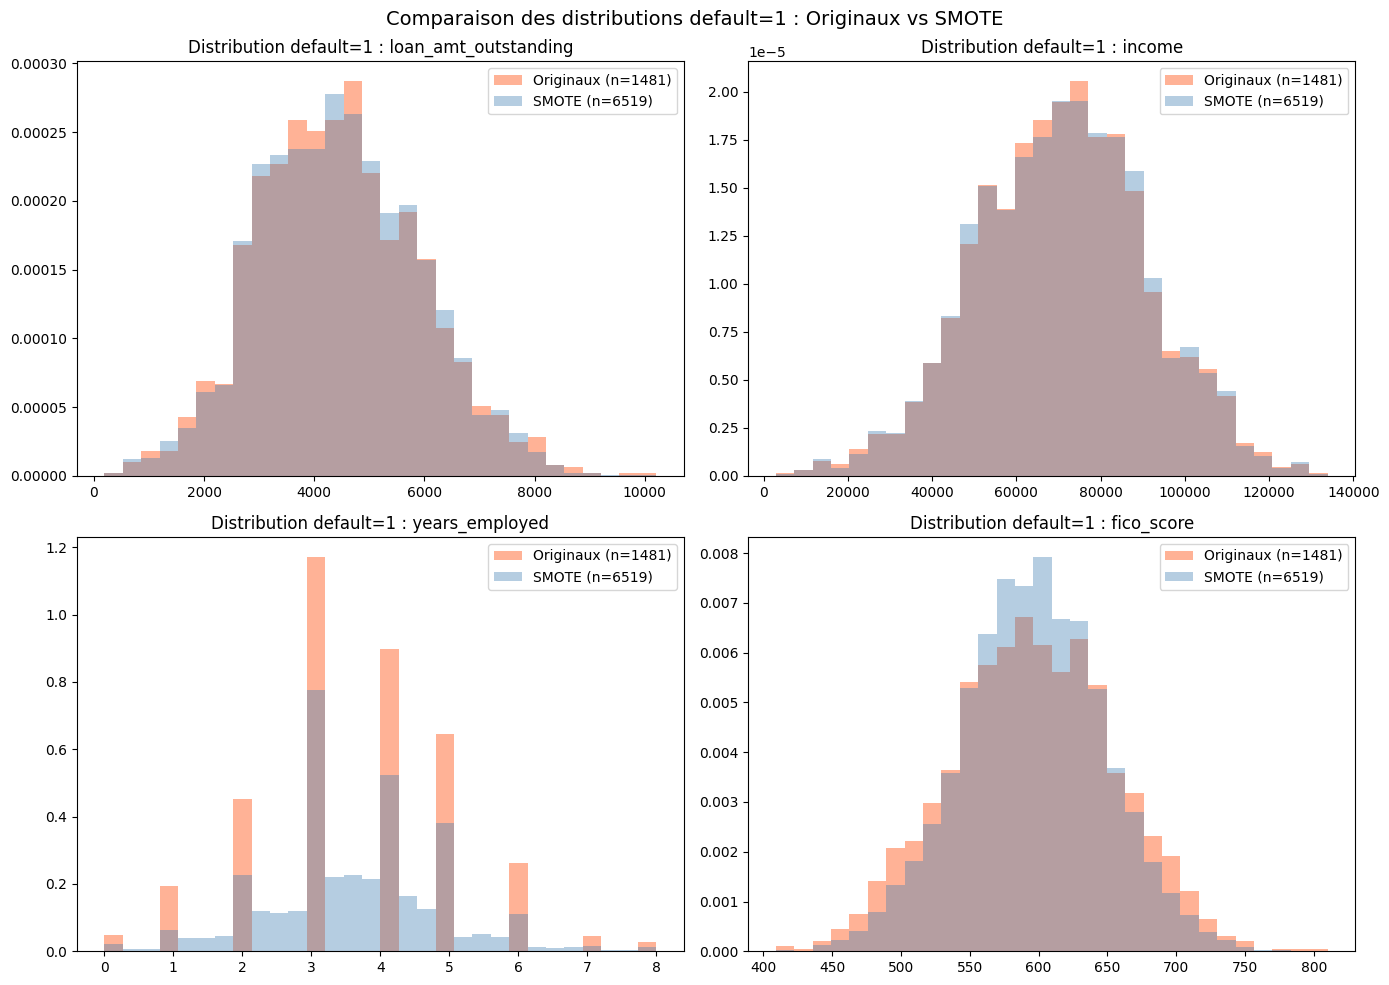

In [201]:
# ====================================
#  SMOTE : Génération de défauts synthétiques
# ====================================



var_smote = True

smote = SMOTE(random_state=seeds, k_neighbors=5)

# On applique SMOTE sur le train set UNIQUEMENT
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== Avant SMOTE (train) ===")
print(f"  Total : {len(y_train)}")
print(f"  Default=0 : {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"  Default=1 : {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")

print(f"\n=== Apres SMOTE (train) ===")
print(f"  Total : {len(y_train_smote)}")
print(f"  Default=0 : {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean():.1%})")
print(f"  Default=1 : {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean():.1%})")

n_synthetiques = len(y_train_smote) - len(y_train)
print(f"\n  => {n_synthetiques} échantillons default=1 générés par SMOTE")

# Visualisation : comparaison distributions avant/apres SMOTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# [FIX] feature_names sauvegardé avant la conversion numpy
feature_cols = feature_names

for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx // 2][idx % 2]
    
    # Originaux default=1
    orig_default = X_train[y_train == 1, idx]
    # SMOTE default=1 (inclut originaux + synthetiques)
    smote_default = pd.Series(
        X_train_smote[y_train_smote == 1][col].values if hasattr(X_train_smote, 'columns')
        else X_train_smote[y_train_smote == 1, idx],
        name=col
    )
    
    ax.hist(orig_default, bins=30, alpha=0.6, label=f'Originaux (n={len(orig_default)})', color='coral', density=True)
    ax.hist(smote_default, bins=30, alpha=0.4, label=f'SMOTE (n={len(smote_default)})', color='steelblue', density=True)
    ax.set_title(f'Distribution default=1 : {col}')
    ax.legend()

plt.suptitle('Comparaison des distributions default=1 : Originaux vs SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

  COMPARAISON : Modèles originaux vs Modèles entraînés avec SMOTE

  Logistic Regression
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------


c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
2026/04/03 16:28:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy                   0.6685       0.3450   -0.3235 ↓
Recall                     0.7595       0.9838   +0.2243 ↑
Precision                  0.3287       0.2182   -0.1104 ↓
F1-score                   0.4588       0.3572   -0.1016 ↓
AUC-ROC                    0.7823       0.7823   +0.0000 ≈


2026/04/03 16:28:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Random Forest
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy                   0.6690       0.3670   -0.3020 ↓
Recall                     0.7162       0.9784   +0.2622 ↑


...

2026/04/03 16:28:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 16:28:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy                   0.6730       0.4645   -0.2085 ↓
Recall                     0.7081       0.9486   +0.2405 ↑
Precision                  0.3243       0.2502   -0.0741 ↓
F1-score                   0.4448       0.3959   -0.0489 ↓
AUC-ROC                    0.7674       0.7720   +0.0046 ≈


2026/04/03 16:28:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/04/03 16:29:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  MLP Classifier
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy                   0.8240       0.6935   -0.1305 ↓
Recall                     0.2216       0.6703   +0.4486 ↑
Precision                  0.5616       0.3356   -0.2261 ↓
F1-score                   0.3178       0.4472   +0.1294 ↑
AUC-ROC                    0.7372       0.7481   +0.0108 ↑


2026/04/03 16:29:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


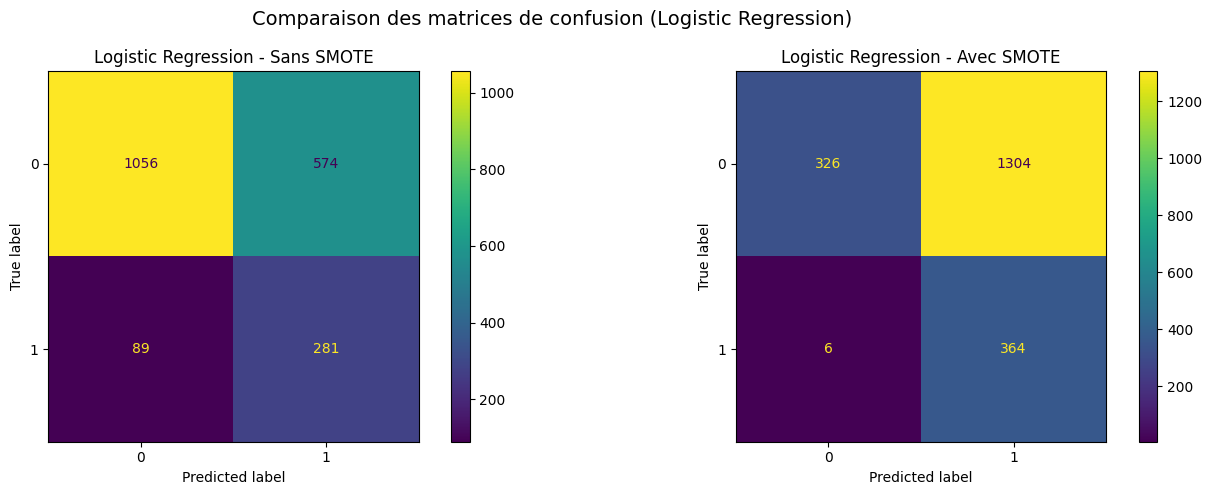


Meilleur modèle (recall sur test) : Logistic Regression
SMOTE améliore généralement le recall (détection des défauts)
au prix d'une légère baisse de précision (plus de faux positifs).


In [202]:
# ====================================
#  Ré-entraînement avec SMOTE et comparaison
# ====================================
# On ré-entraîne les modèles sur les données équilibrées par SMOTE
# et on compare les performances sur le MEME test set (non modifie)

best_models_smote = {}
print("=" * 70)
print("  COMPARAISON : Modèles originaux vs Modèles entraînés avec SMOTE")
print("=" * 70)

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", sklearn.base.clone(model))
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=gridsearch_params[name],
        cv=stratifiedkfold,
        scoring="recall",
        n_jobs=-1,
        refit=True
    )

    # Entrainement sur donnees SMOTE
    grid.fit(X_train_smote, y_train_smote)

    best_smote = grid.best_estimator_
    best_models_smote[name] = best_smote

    # Predictions sur le test set (JAMAIS touche par SMOTE)
    y_pred_orig = best_models[name].predict(X_test)
    y_pred_smote = best_smote.predict(X_test)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"{'Metrique':<20} {'Sans SMOTE':>12} {'Avec SMOTE':>12} {'Delta':>10}")
    print(f"{'-'*55}")

    # [MLF0] Tracking MLflow pour les modèles SMOTE
    with mlflow.start_run(run_name=f"{name}_SMOTE"):
        mlflow.log_params(grid.best_params_)
        mlflow.log_param("model_type", name)
        mlflow.log_param("cv_folds", 5)
        mlflow.log_param("scoring", "recall")
        mlflow.log_param("random_state", seeds)
        mlflow.log_param("smote_k_neighbors", 5)
        mlflow.set_tag("smote", "true")
        mlflow.set_tag("features", str(list(X.columns)))
        mlflow.log_metric("best_cv_recall", grid.best_score_)

        for metric_name, metric_fn in [
            ("Accuracy", accuracy_score),
            ("Recall", recall_score),
            ("Precision", precision_score),
            ("F1-score", f1_score),
        ]:
            score_orig = metric_fn(y_test, y_pred_orig)
            score_smote = metric_fn(y_test, y_pred_smote)
            delta = score_smote - score_orig
            arrow = "\u2191" if delta > 0.005 else ("\u2193" if delta < -0.005 else "\u2248")
            print(f"{metric_name:<20} {score_orig:>12.4f} {score_smote:>12.4f} {delta:>+9.4f} {arrow}")

            # [MLF0] Log des métriques test et des deltas
            metric_key = metric_name.lower().replace("-", "_")
            mlflow.log_metric(f"test_{metric_key}", score_smote)
            mlflow.log_metric(f"delta_{metric_key}", delta)

        # AUC-ROC si le modele supporte predict_proba
        try:
            proba_orig = best_models[name].predict_proba(X_test)[:, 1]
            proba_smote = best_smote.predict_proba(X_test)[:, 1]
            auc_orig = roc_auc_score(y_test, proba_orig)
            auc_smote = roc_auc_score(y_test, proba_smote)
            delta_auc = auc_smote - auc_orig
            arrow = "\u2191" if delta_auc > 0.005 else ("\u2193" if delta_auc < -0.005 else "\u2248")
            print(f"{'AUC-ROC':<20} {auc_orig:>12.4f} {auc_smote:>12.4f} {delta_auc:>+9.4f} {arrow}")
            mlflow.log_metric("test_auc_roc", auc_smote)
            mlflow.log_metric("delta_auc_roc", delta_auc)
        except AttributeError:
            pass

        # [MLF0] Sauvegarde du modèle SMOTE
        mlflow.sklearn.log_model(best_smote, artifact_path="model")

# Matrices de confusion comparees (meilleur modele)
best_name = max(best_models_smote.keys(),
                key=lambda k: recall_score(y_test, best_models_smote[k].predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, best_models[best_name].predict(X_test), ax=axes[0])
axes[0].set_title(f'{best_name} - Sans SMOTE')

ConfusionMatrixDisplay.from_predictions(y_test, best_models_smote[best_name].predict(X_test), ax=axes[1])
axes[1].set_title(f'{best_name} - Avec SMOTE')

plt.suptitle(f'Comparaison des matrices de confusion ({best_name})', fontsize=14)
plt.tight_layout()
plt.show()

# [MLF0] Sauvegarde de la comparaison SMOTE comme artifact
fig.savefig("comparison_smote_confusion.png", bbox_inches='tight')
with mlflow.start_run(run_name="SMOTE_Comparison_ConfusionMatrix"):
    mlflow.log_artifact("comparison_smote_confusion.png")
    mlflow.set_tag("artifact_type", "smote_comparison")
os.remove("comparison_smote_confusion.png")

print(f"\nMeilleur modèle (recall sur test) : {best_name}")
print("SMOTE améliore généralement le recall (détection des défauts)")
print("au prix d'une légère baisse de précision (plus de faux positifs).")

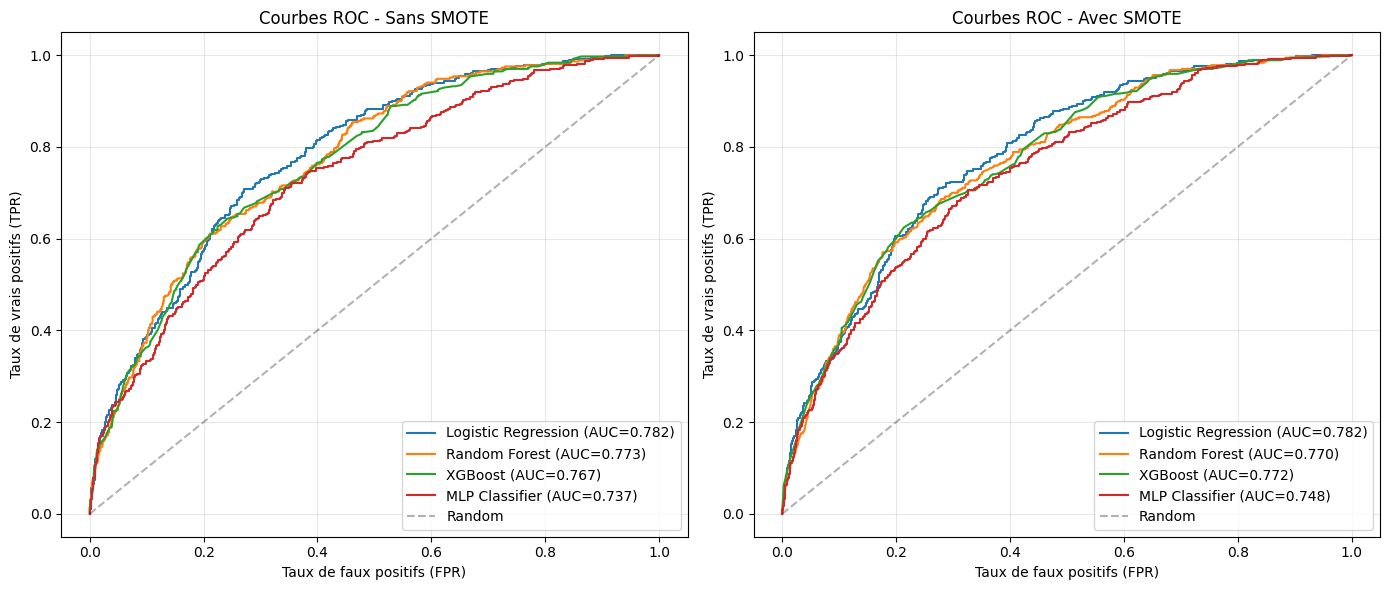

L'AUC-ROC mesure la capacité globale de discrimination du modèle.
Si AUC augmente avec SMOTE, le modèle bénéficie de l'équilibrage des classes.

  MLflow : Tracking terminé
  URI : mlruns
  Experiment : ProjetMLOPS-LoanDefaultV2
  Pour visualiser : mlflow ui


In [203]:
# ====================================
#  Courbes ROC comparatives : Sans SMOTE vs Avec SMOTE
# ====================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, models_dict) in zip(axes, [("Sans SMOTE", best_models), ("Avec SMOTE", best_models_smote)]):
    for name, mdl in models_dict.items():
        try:
            y_proba = mdl.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
        except AttributeError:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set_title(f'Courbes ROC - {label}')
    ax.set_xlabel('Taux de faux positifs (FPR)')
    ax.set_ylabel('Taux de vrais positifs (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("L'AUC-ROC mesure la capacité globale de discrimination du modèle.")
print("Si AUC augmente avec SMOTE, le modèle bénéficie de l'équilibrage des classes.")

# [MLF0] Sauvegarde des courbes ROC comme artifact MLflow
fig.savefig("roc_curves_comparison.png", bbox_inches='tight')
with mlflow.start_run(run_name="ROC_Curves_Comparison"):
    mlflow.log_artifact("roc_curves_comparison.png")
    mlflow.set_tag("artifact_type", "roc_comparison")
os.remove("roc_curves_comparison.png")

# [MLF0] Résumé final MLflow
print("\n" + "="*50)
print("  MLflow : Tracking terminé")
print("="*50)
print(f"  URI : {mlflow.get_tracking_uri()}")
print(f"  Experiment : ProjetMLOPS-LoanDefaultV2")
print("  Pour visualiser : mlflow ui")

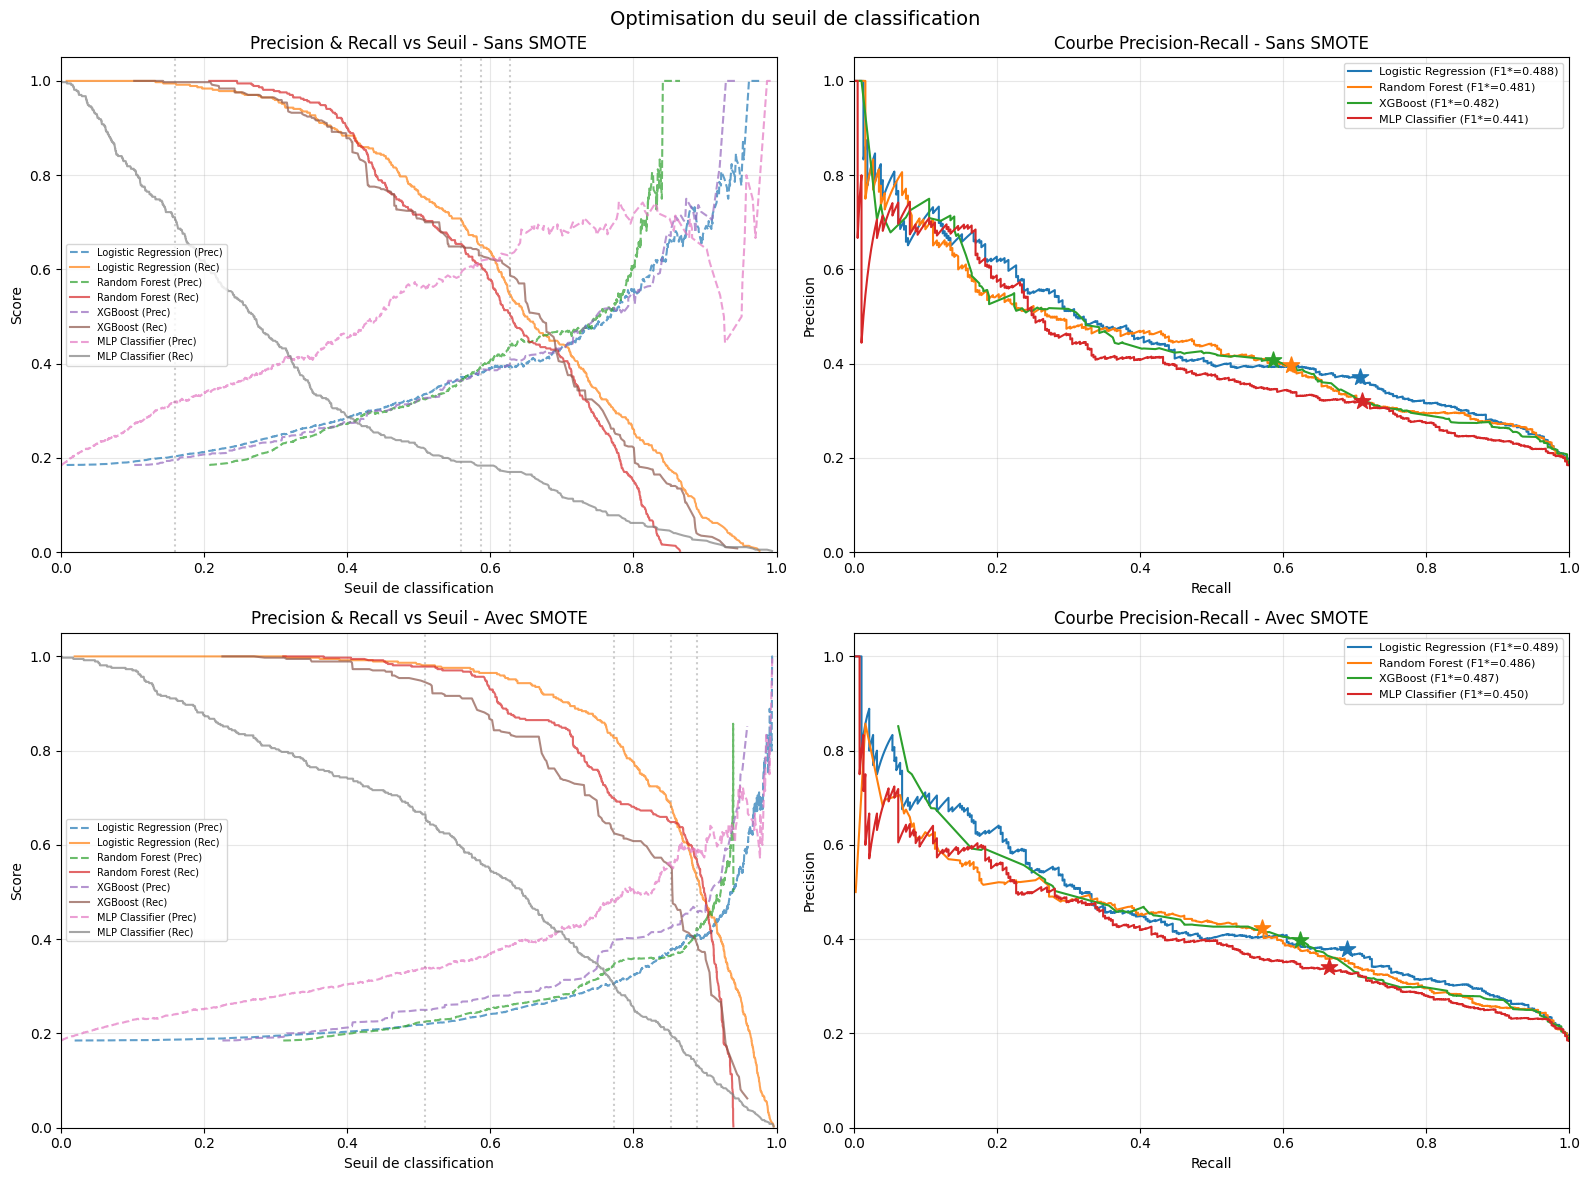


  Seuils optimaux par modele (maximisant le F1-score)
  Variante              Modele  Seuil optimal (F1)  Precision  Recall  F1-score
Sans SMOTE Logistic Regression              0.5586     0.3722  0.7081    0.4879
Sans SMOTE       Random Forest              0.5870     0.3965  0.6108    0.4809
Sans SMOTE             XGBoost              0.6276     0.4087  0.5865    0.4817
Sans SMOTE      MLP Classifier              0.1589     0.3200  0.7108    0.4413
Avec SMOTE Logistic Regression              0.8520     0.3783  0.6892    0.4885
Avec SMOTE       Random Forest              0.8887     0.4237  0.5703    0.4862
Avec SMOTE             XGBoost              0.7732     0.3990  0.6243    0.4868
Avec SMOTE      MLP Classifier              0.5091     0.3402  0.6649    0.4501

Application du seuil optimal : Logistic Regression avec seuil = 0.852


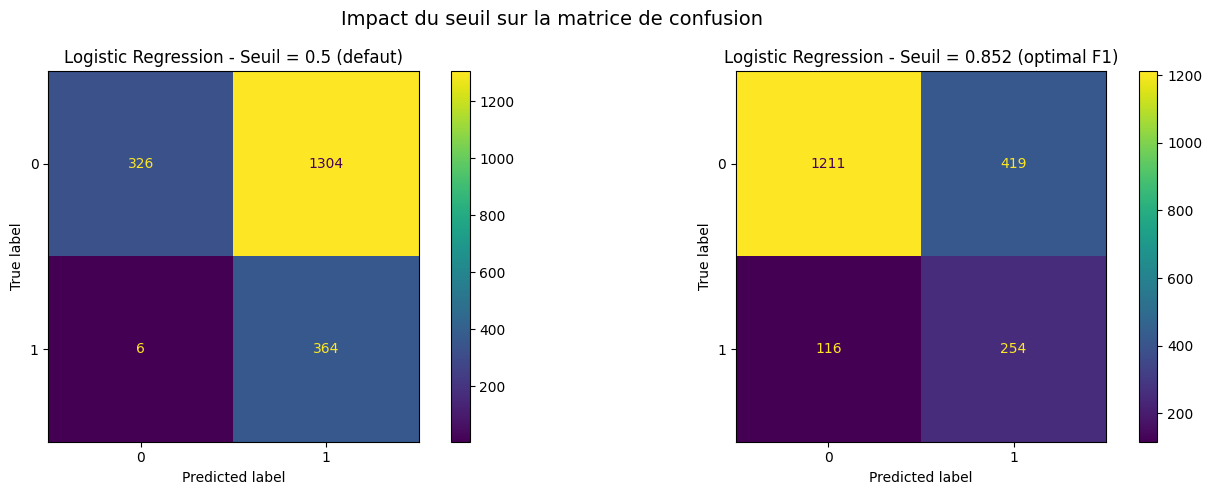


Metrique                Seuil 0.5  Seuil optimal
------------------------------------------------
Accuracy                   0.3450         0.7325
Recall                     0.9838         0.6865
Precision                  0.2182         0.3774
F1-score                   0.3572         0.4871

Le seuil optimal (0.852) permet d'ajuster le compromis precision/recall.
Un seuil plus bas augmente le recall (plus de defauts detectes) au prix de la precision.

[MLflow] Seuil optimal et metriques enregistres.


In [204]:
# ====================================
#  Optimisation du seuil de classification
# ====================================
# Par defaut, predict() utilise un seuil de 0.5. Pour un probleme desequilibre
# (18.5% de defauts), ce seuil n'est pas optimal. On trace les courbes
# Precision-Recall en fonction du seuil pour chaque modele, afin de choisir
# le seuil qui offre le meilleur compromis.

from sklearn.metrics import precision_recall_curve

# ====================================
#  1. Courbes Precision-Recall vs Seuil (Sans SMOTE / Avec SMOTE)
# ====================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

threshold_results = []

for row_idx, (label, models_dict) in enumerate([("Sans SMOTE", best_models), ("Avec SMOTE", best_models_smote)]):
    for name, mdl in models_dict.items():
        try:
            y_proba = mdl.predict_proba(X_test)[:, 1]
        except AttributeError:
            continue

        precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

        # Calcul du F1 pour chaque seuil
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        best_prec = precisions[best_idx]
        best_rec = recalls[best_idx]

        threshold_results.append({
            "Variante": label,
            "Modele": name,
            "Seuil optimal (F1)": round(float(best_threshold), 4),
            "Precision": round(float(best_prec), 4),
            "Recall": round(float(best_rec), 4),
            "F1-score": round(float(best_f1), 4)
        })

        # Graphique Precision & Recall vs Seuil
        ax = axes[row_idx, 0]
        ax.plot(thresholds, precisions[:-1], label=f"{name} (Prec)", linestyle="--", alpha=0.7)
        ax.plot(thresholds, recalls[:-1], label=f"{name} (Rec)", alpha=0.7)
        ax.axvline(x=best_threshold, color="gray", linestyle=":", alpha=0.4)

        # Graphique Precision vs Recall
        ax2 = axes[row_idx, 1]
        ax2.plot(recalls[:-1], precisions[:-1], label=f"{name} (F1*={best_f1:.3f})")
        ax2.scatter([best_rec], [best_prec], marker="*", s=150, zorder=5)

    axes[row_idx, 0].set_title(f"Precision & Recall vs Seuil - {label}")
    axes[row_idx, 0].set_xlabel("Seuil de classification")
    axes[row_idx, 0].set_ylabel("Score")
    axes[row_idx, 0].legend(fontsize=7, loc="center left")
    axes[row_idx, 0].set_xlim(0, 1)
    axes[row_idx, 0].set_ylim(0, 1.05)
    axes[row_idx, 0].grid(True, alpha=0.3)

    axes[row_idx, 1].set_title(f"Courbe Precision-Recall - {label}")
    axes[row_idx, 1].set_xlabel("Recall")
    axes[row_idx, 1].set_ylabel("Precision")
    axes[row_idx, 1].legend(fontsize=8)
    axes[row_idx, 1].set_xlim(0, 1)
    axes[row_idx, 1].set_ylim(0, 1.05)
    axes[row_idx, 1].grid(True, alpha=0.3)

plt.suptitle("Optimisation du seuil de classification", fontsize=14)
plt.tight_layout()
plt.show()

# ====================================
#  2. Tableau recapitulatif des seuils optimaux
# ====================================
threshold_df = pd.DataFrame(threshold_results)
print("\n" + "="*70)
print("  Seuils optimaux par modele (maximisant le F1-score)")
print("="*70)
print(threshold_df.to_string(index=False))

# ====================================
#  3. Application du seuil optimal sur le meilleur modele
# ====================================
# On selectionne le meilleur modele SMOTE (F1 max) et on applique son seuil optimal
best_row = threshold_df[threshold_df["Variante"] == "Avec SMOTE"].sort_values("F1-score", ascending=False).iloc[0]
best_name_threshold = best_row["Modele"]
best_seuil = best_row["Seuil optimal (F1)"]

print(f"\nApplication du seuil optimal : {best_name_threshold} avec seuil = {best_seuil}")

y_proba_best = best_models_smote[best_name_threshold].predict_proba(X_test)[:, 1]

# Predictions avec seuil par defaut (0.5) vs seuil optimal
y_pred_default = (y_proba_best >= 0.5).astype(int)
y_pred_optimal = (y_proba_best >= best_seuil).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default, ax=axes[0])
axes[0].set_title(f"{best_name_threshold} - Seuil = 0.5 (defaut)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal, ax=axes[1])
axes[1].set_title(f"{best_name_threshold} - Seuil = {best_seuil} (optimal F1)")

plt.suptitle("Impact du seuil sur la matrice de confusion", fontsize=14)
plt.tight_layout()
plt.show()

# Comparaison des metriques
print(f"\n{'Metrique':<20} {'Seuil 0.5':>12} {'Seuil optimal':>14}")
print(f"{'-'*48}")
for metric_name, metric_fn in [("Accuracy", accuracy_score), ("Recall", recall_score), ("Precision", precision_score), ("F1-score", f1_score)]:
    s_def = metric_fn(y_test, y_pred_default)
    s_opt = metric_fn(y_test, y_pred_optimal)
    print(f"{metric_name:<20} {s_def:>12.4f} {s_opt:>14.4f}")

print(f"\nLe seuil optimal ({best_seuil}) permet d'ajuster le compromis precision/recall.")
print("Un seuil plus bas augmente le recall (plus de defauts detectes) au prix de la precision.")

# [MLF0] Enregistrement des seuils optimaux dans MLflow
fig.savefig("threshold_comparison.png", bbox_inches='tight')

with mlflow.start_run(run_name="Threshold_Optimization"):
    mlflow.set_tag("artifact_type", "threshold_optimization")
    mlflow.log_artifact("threshold_comparison.png")

    # Log du seuil optimal et metriques recalculees pour le meilleur modele
    mlflow.log_param("best_model", best_name_threshold)
    mlflow.log_param("optimal_threshold", best_seuil)
    mlflow.log_metric("threshold_accuracy", accuracy_score(y_test, y_pred_optimal))
    mlflow.log_metric("threshold_recall", recall_score(y_test, y_pred_optimal))
    mlflow.log_metric("threshold_precision", precision_score(y_test, y_pred_optimal))
    mlflow.log_metric("threshold_f1", f1_score(y_test, y_pred_optimal))

    # Log de tous les seuils optimaux par modele
    for _, row in threshold_df.iterrows():
        tag_key = f"seuil_{row['Variante']}_{row['Modele']}".replace(" ", "_")
        mlflow.set_tag(tag_key, str(row["Seuil optimal (F1)"]))

os.remove("threshold_comparison.png")

print("\n[MLflow] Seuil optimal et metriques enregistres.")